**# Online Shopper Purchase Prediction using Machine Learning

## Project Overview

This project aims to predict whether an online customer will complete a purchase based on their browsing behaviour. Several supervised machine learning algorithms were developed and compared to identify the best-performing model. The final model was further interpreted using Explainable AI (SHAP) to understand the key factors influencing customer purchase decisions.

**## Objectives

The objectives of this project are:

- Predict whether a visitor will purchase a product.
- Compare multiple machine learning algorithms.
- Handle class imbalance appropriately.
- Evaluate models using multiple performance metrics.
- Improve performance using hyperparameter tuning.
- Explain model predictions using SHAP.

**## Dataset

Dataset: Online Shoppers Purchasing Intention Dataset

Target Variable:
- Revenue
    - True = Purchase
    - False = No Purchase

The dataset contains customer browsing behaviour including:

- Administrative pages
- Informational pages
- Product-related pages
- Bounce rate
- Exit rate
- Page values
- Visitor type
- Month
- Weekend visits

In [184]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [185]:
df = pd.read_csv("K:\let's do it\online_shoppers_intention.csv")

In [186]:
print(df.head())

   Administrative  Administrative_Duration  Informational  \
0               0                      0.0              0   
1               0                      0.0              0   
2               0                      0.0              0   
3               0                      0.0              0   
4               0                      0.0              0   

   Informational_Duration  ProductRelated  ProductRelated_Duration  \
0                     0.0               1                 0.000000   
1                     0.0               2                64.000000   
2                     0.0               1                 0.000000   
3                     0.0               2                 2.666667   
4                     0.0              10               627.500000   

   BounceRates  ExitRates  PageValues  SpecialDay Month  OperatingSystems  \
0         0.20       0.20         0.0         0.0   Feb                 1   
1         0.00       0.10         0.0         0.0   Feb   

In [187]:
print(df.shape)

(12330, 18)


In [188]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [189]:
print(df.describe())

       Administrative  Administrative_Duration  Informational  \
count    12330.000000             12330.000000   12330.000000   
mean         2.315166                80.818611       0.503569   
std          3.321784               176.779107       1.270156   
min          0.000000                 0.000000       0.000000   
25%          0.000000                 0.000000       0.000000   
50%          1.000000                 7.500000       0.000000   
75%          4.000000                93.256250       0.000000   
max         27.000000              3398.750000      24.000000   

       Informational_Duration  ProductRelated  ProductRelated_Duration  \
count            12330.000000    12330.000000             12330.000000   
mean                34.472398       31.731468              1194.746220   
std                140.749294       44.475503              1913.669288   
min                  0.000000        0.000000                 0.000000   
25%                  0.000000        7.00000

In [190]:
print(df.isnull().sum())

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64


In [191]:
print(df.duplicated().sum())

125


In [192]:
print(df[df.duplicated()].head())

     Administrative  Administrative_Duration  Informational  \
158               0                      0.0              0   
159               0                      0.0              0   
178               0                      0.0              0   
418               0                      0.0              0   
456               0                      0.0              0   

     Informational_Duration  ProductRelated  ProductRelated_Duration  \
158                     0.0               1                      0.0   
159                     0.0               1                      0.0   
178                     0.0               1                      0.0   
418                     0.0               1                      0.0   
456                     0.0               1                      0.0   

     BounceRates  ExitRates  PageValues  SpecialDay Month  OperatingSystems  \
158          0.2        0.2         0.0         0.0   Feb                 1   
159          0.2        0.2   

In [193]:
print(df["Revenue"].value_counts())

False    10422
True      1908
Name: Revenue, dtype: int64


**# Exploratory Data Analysis (EDA)

Exploratory Data Analysis was performed to understand the characteristics of the dataset, identify class imbalance, examine feature distributions, and discover relationships between customer behaviour and purchase intention.

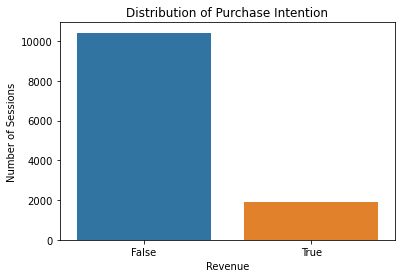

In [194]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Revenue")

plt.title("Distribution of Purchase Intention")
plt.xlabel("Revenue")
plt.ylabel("Number of Sessions")

plt.show()

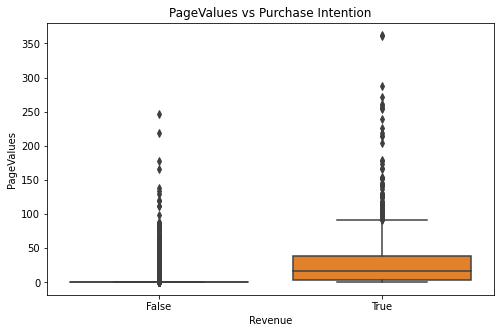

In [195]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="Revenue", y="PageValues")

plt.title("PageValues vs Purchase Intention")
plt.xlabel("Revenue")
plt.ylabel("PageValues")

plt.show()

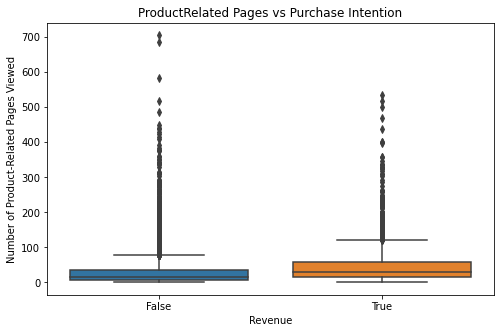

In [196]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Revenue",
    y="ProductRelated"
)

plt.title("ProductRelated Pages vs Purchase Intention")
plt.xlabel("Revenue")
plt.ylabel("Number of Product-Related Pages Viewed")

plt.show()

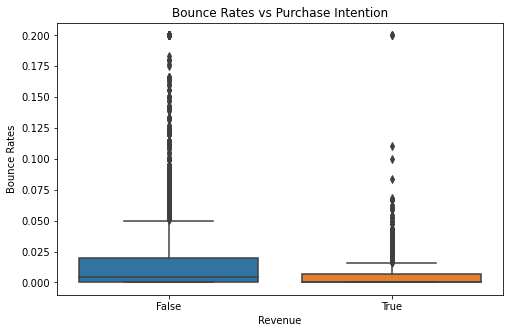

In [197]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Revenue",
    y="BounceRates"
)

plt.title("Bounce Rates vs Purchase Intention")
plt.xlabel("Revenue")
plt.ylabel("Bounce Rates")

plt.show()

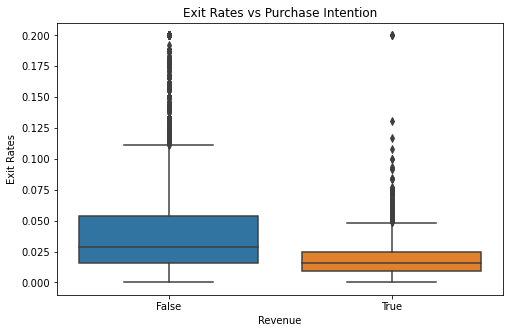

In [198]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Revenue",
    y="ExitRates"
)

plt.title("Exit Rates vs Purchase Intention")
plt.xlabel("Revenue")
plt.ylabel("Exit Rates")

plt.show()

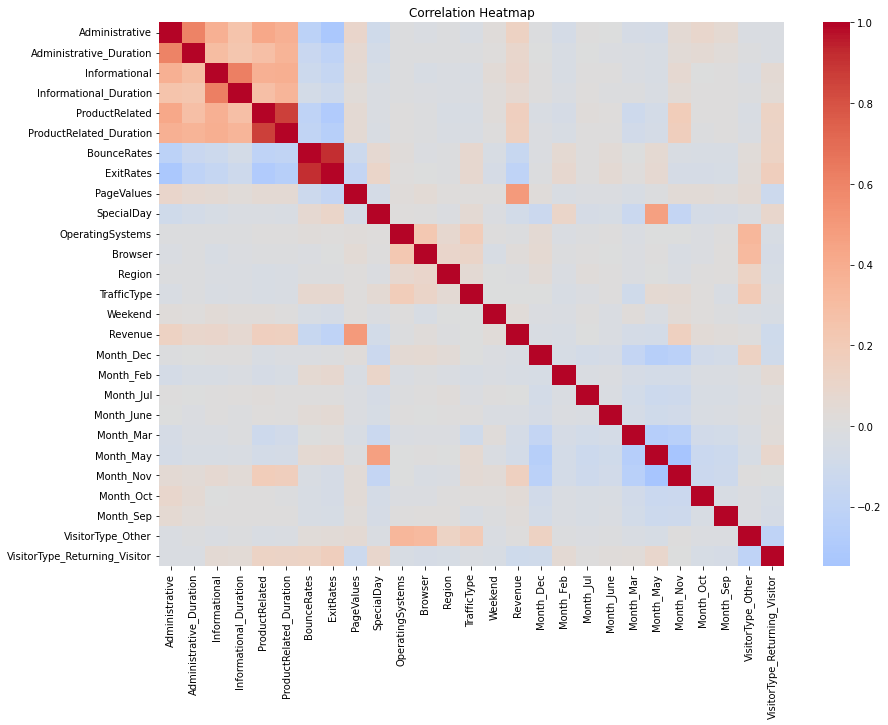

In [199]:
# Convert True/False into 1/0
corr_df = df.copy()

corr_df["Revenue"] = corr_df["Revenue"].astype(int)
corr_df["Weekend"] = corr_df["Weekend"].astype(int)

# Convert text columns to numbers
corr_df = pd.get_dummies(
    corr_df,
    columns=["Month", "VisitorType"],
    drop_first=True
)

# Keep only numeric columns
numeric_df = corr_df.select_dtypes(include=["number"])

# Correlation matrix
corr_matrix = numeric_df.corr()

# Plot
plt.figure(figsize=(14,10))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")

plt.show()

In [200]:
pd.crosstab(df["Month"], df["Revenue"])

Revenue,False,True
Month,,
Aug,357,76
Dec,1511,216
Feb,181,3
Jul,366,66
June,259,29
Mar,1715,192
May,2999,365
Nov,2238,760
Oct,434,115


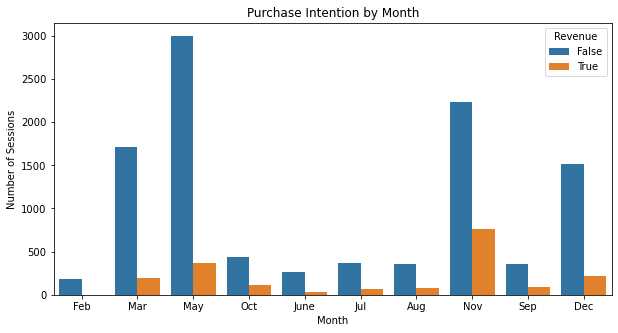

In [201]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="Month",
    hue="Revenue"
)

plt.title("Purchase Intention by Month")
plt.xlabel("Month")
plt.ylabel("Number of Sessions")

plt.show()

In [202]:
pd.crosstab(df["VisitorType"], df["Revenue"])

Revenue,False,True
VisitorType,,
New_Visitor,1272,422
Other,69,16
Returning_Visitor,9081,1470


In [203]:
visitor_rate = pd.crosstab(
    df["VisitorType"],
    df["Revenue"],
    normalize="index"
)

print(visitor_rate)

Revenue               False      True
VisitorType                          
New_Visitor        0.750885  0.249115
Other              0.811765  0.188235
Returning_Visitor  0.860677  0.139323


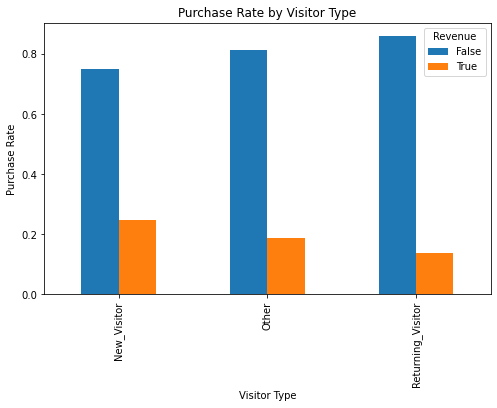

In [204]:
visitor_rate.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Purchase Rate by Visitor Type")
plt.xlabel("Visitor Type")
plt.ylabel("Purchase Rate")

plt.show()

In [205]:
X = df.drop("Revenue", axis=1)

y = df["Revenue"]

In [206]:
print(X.shape)
print(y.shape)

(12330, 17)
(12330,)


In [207]:
print(X.dtypes)

Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                       object
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                 object
Weekend                       bool
dtype: object


**# Data Preprocessing

**# One-hot encoding

In [208]:
X = pd.get_dummies(
    X,
    columns=["Month", "VisitorType"],
    drop_first=True
)

In [209]:
print(X.shape)

print(X.columns)

(12330, 26)
Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'Weekend',
       'Month_Dec', 'Month_Feb', 'Month_Jul', 'Month_June', 'Month_Mar',
       'Month_May', 'Month_Nov', 'Month_Oct', 'Month_Sep', 'VisitorType_Other',
       'VisitorType_Returning_Visitor'],
      dtype='object')


**Train-test split

In [210]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [211]:
print(X_train.shape)
print(X_test.shape)

print(y_train.value_counts(normalize=True))
print()

print(y_test.value_counts(normalize=True))

(9864, 26)
(2466, 26)
False    0.845296
True     0.154704
Name: Revenue, dtype: float64

False    0.845093
True     0.154907
Name: Revenue, dtype: float64


**# Feature Scaling

In [212]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [213]:
print(X_train_scaled[:5])

[[ 1.7120884   3.62474482 -0.39578211 -0.24458924  0.05840527  0.08339286
  -0.3537925  -0.61292345  0.3410137   3.66343985  0.9503449   0.36544319
  -0.06376855 -0.51585403 -0.5492383  -0.40517717 -0.12257107 -0.19009065
  -0.1538222  -0.42979362  1.62766046 -0.56080205 -0.2171031  -0.19685822
  -0.08694098  0.41025005]
 [-0.69829357 -0.45234111 -0.39578211 -0.24458924 -0.62945941 -0.539163
   0.36069829  1.15926204 -0.3202677  -0.31149918 -1.2281822   3.2510753
  -0.06376855 -0.76491836  1.82070333 -0.40517717 -0.12257107 -0.19009065
  -0.1538222  -0.42979362 -0.61437875 -0.56080205  4.60610641 -0.19685822
  -0.08694098  0.41025005]
 [-0.69829357 -0.45234111 -0.39578211 -0.24458924 -0.62945941 -0.59950381
  -0.45886467  0.13674565 -0.3202677  -0.31149918 -0.13891865  4.40532814
  -0.89855681 -0.51585403 -0.5492383   2.46805616 -0.12257107 -0.19009065
  -0.1538222  -0.42979362 -0.61437875 -0.56080205 -0.2171031  -0.19685822
  -0.08694098  0.41025005]
 [-0.09569808  1.42960501 -0.39578

In [214]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(9864, 26)
(2466, 26)


**# Machine Learning Models

In [215]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [216]:
results = []

In [217]:
def evaluate_model(model, X_train, X_test, y_train, y_test):

    # Train the model
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Probability predictions (needed for ROC-AUC)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")
    
    return {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1,
    "ROC-AUC": roc_auc
}

In [218]:
log_reg = LogisticRegression(random_state=42)

logistic_results = evaluate_model(
    log_reg,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

logistic_results["Model"] = "Logistic Regression"
results.append(logistic_results)

Accuracy : 0.8812
Precision: 0.7432
Recall   : 0.3560
F1 Score : 0.4814
ROC-AUC  : 0.8872


In [219]:
LogisticRegression(
    class_weight="balanced",
    random_state=42
)

LogisticRegression(class_weight='balanced', random_state=42)

In [220]:
log_reg_balanced = LogisticRegression(
    class_weight="balanced",
    random_state=42
)

In [221]:
balanced_results = evaluate_model(
    log_reg_balanced,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)
balanced_results["Model"] = "Balanced Logistic Regression"
results.append(balanced_results)

Accuracy : 0.8500
Precision: 0.5107
Recall   : 0.7487
F1 Score : 0.6072
ROC-AUC  : 0.8962


In [222]:
from sklearn.tree import DecisionTreeClassifier

In [223]:
decision_tree = DecisionTreeClassifier(
    random_state=42
)

dt_results = evaluate_model(
    decision_tree,
    X_train,
    X_test,
    y_train,
    y_test
)

dt_results["Model"] = "Decision Tree"
results.append(dt_results)

Accuracy : 0.8646
Precision: 0.5645
Recall   : 0.5497
F1 Score : 0.5570
ROC-AUC  : 0.7360


In [224]:
print("Training Accuracy:",
      decision_tree.score(X_train, y_train))

print("Testing Accuracy:",
      decision_tree.score(X_test, y_test))

Training Accuracy: 1.0
Testing Accuracy: 0.8645579886455799


In [225]:
from sklearn.ensemble import RandomForestClassifier

In [226]:
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_results = evaluate_model(
    random_forest,
    X_train,
    X_test,
    y_train,
    y_test
)

rf_results["Model"] = "Random Forest"

results.append(rf_results)

Accuracy : 0.8978
Precision: 0.7321
Recall   : 0.5366
F1 Score : 0.6193
ROC-AUC  : 0.9179


In [227]:
print("Training Accuracy:",
      random_forest.score(X_train, y_train))

print("Testing Accuracy:",
      random_forest.score(X_test, y_test))

Training Accuracy: 1.0
Testing Accuracy: 0.8978102189781022


In [228]:
from sklearn.neighbors import KNeighborsClassifier

In [229]:
knn = KNeighborsClassifier(
    n_neighbors=5
)

knn_results = evaluate_model(
    knn,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

knn_results["Model"] = "KNN"
results.append(knn_results)

Accuracy : 0.8686
Precision: 0.6368
Recall   : 0.3534
F1 Score : 0.4545
ROC-AUC  : 0.7725


In [230]:
from sklearn.svm import SVC

In [231]:
svm = SVC(
    kernel="rbf",
    probability=True,
    random_state=42
)

svm_results = evaluate_model(
    svm,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

svm_results["Model"] = "SVM"
results.append(svm_results)

Accuracy : 0.8844
Precision: 0.7012
Recall   : 0.4424
F1 Score : 0.5425
ROC-AUC  : 0.8736


In [232]:
from sklearn.naive_bayes import GaussianNB

In [233]:
naive_bayes = GaussianNB()

nb_results = evaluate_model(
    naive_bayes,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

nb_results["Model"] = "Gaussian Naive Bayes"
results.append(nb_results)

Accuracy : 0.6764
Precision: 0.2977
Recall   : 0.8010
F1 Score : 0.4340
ROC-AUC  : 0.7974


**# Model Comparison

In [234]:
comparison_df = pd.DataFrame(results)

comparison_df

,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Model
0,0.881184,0.743169,0.356021,0.481416,0.887201,Logistic Regression
1,0.849959,0.510714,0.748691,0.607219,0.896243,Balanced Logistic Regression
2,0.864558,0.564516,0.549738,0.557029,0.736002,Decision Tree
3,0.897810,0.732143,0.536649,0.619335,0.917944,Random Forest
4,0.868613,0.636792,0.353403,0.454545,0.772459,KNN
5,0.884428,0.701245,0.442408,0.542536,0.873646,SVM
6,0.676399,0.297665,0.801047,0.434043,0.797426,Gaussian Naive Bayes


In [235]:
comparison_df = comparison_df.sort_values(
    by="F1 Score",
    ascending=False
)

comparison_df

,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Model
3,0.897810,0.732143,0.536649,0.619335,0.917944,Random Forest
1,0.849959,0.510714,0.748691,0.607219,0.896243,Balanced Logistic Regression
2,0.864558,0.564516,0.549738,0.557029,0.736002,Decision Tree
5,0.884428,0.701245,0.442408,0.542536,0.873646,SVM
0,0.881184,0.743169,0.356021,0.481416,0.887201,Logistic Regression
4,0.868613,0.636792,0.353403,0.454545,0.772459,KNN
6,0.676399,0.297665,0.801047,0.434043,0.797426,Gaussian Naive Bayes


**# Hyperparameter Tuning

Hyperparameter tuning was performed to optimize the Random Forest model using RandomizedSearchCV with 5-fold cross-validation. Multiple combinations of hyperparameters were evaluated, including the number of trees, maximum tree depth, minimum samples required for splitting and leaf nodes, and the number of features considered at each split.

The best-performing parameter combination was selected based on cross-validation performance and then evaluated on the unseen test dataset.

In [236]:
from sklearn.model_selection import RandomizedSearchCV

In [237]:
param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [5, 10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

In [238]:
rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=20,
    scoring="f1",
    cv=5,
    random_state=42,
    n_jobs=-1
)

In [239]:
rf_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'max_depth': [5, 10, 20, None],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 500]},
                   random_state=42, scoring='f1')

In [240]:
print(rf_search.best_params_)

{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 20}


In [241]:
print(rf_search.best_score_)

0.6608272600222367


In [242]:
best_rf = rf_search.best_estimator_

rf_tuned_results = evaluate_model(
    best_rf,
    X_train,
    X_test,
    y_train,
    y_test
)

rf_tuned_results["Model"] = "Random Forest (Tuned)"

results.append(rf_tuned_results)

Accuracy : 0.9015
Precision: 0.7491
Recall   : 0.5471
F1 Score : 0.6324
ROC-AUC  : 0.9208


**### Best Hyperparameters

The optimal Random Forest configuration identified by RandomizedSearchCV was:

- Number of Trees (n_estimators): 100
- Maximum Depth (max_depth): 20
- Minimum Samples Split (min_samples_split): 5
- Minimum Samples Leaf (min_samples_leaf): 4
- Maximum Features (max_features): sqrt

These parameters improved the generalization performance of the Random Forest model while reducing the risk of overfitting.

**Feature Importance

In [243]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
8,PageValues,0.495533
7,ExitRates,0.079798
5,ProductRelated_Duration,0.076891
4,ProductRelated,0.060476
6,BounceRates,0.051293
1,Administrative_Duration,0.047019
0,Administrative,0.034739
21,Month_Nov,0.025180
12,Region,0.021227
13,TrafficType,0.019252


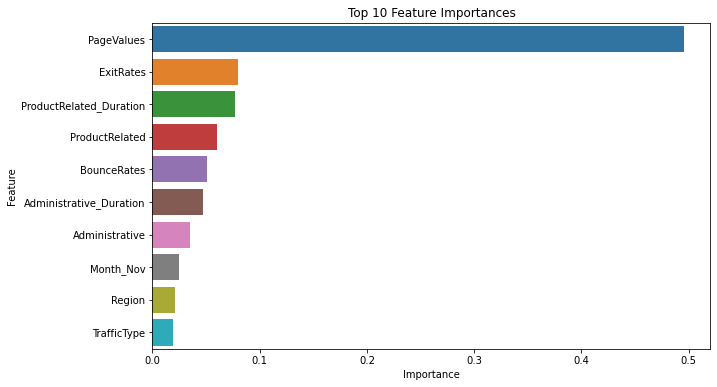

In [244]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

**# Explainable AI using SHAP

In [245]:
!pip install shap

In [246]:
import shap

print(shap.__version__)

0.49.1


In [247]:
explainer = shap.TreeExplainer(best_rf)

shap_values = explainer.shap_values(X_test)

In [248]:
type(shap_values)

numpy.ndarray

In [249]:
print(shap_values.shape)

(2466, 26, 2)


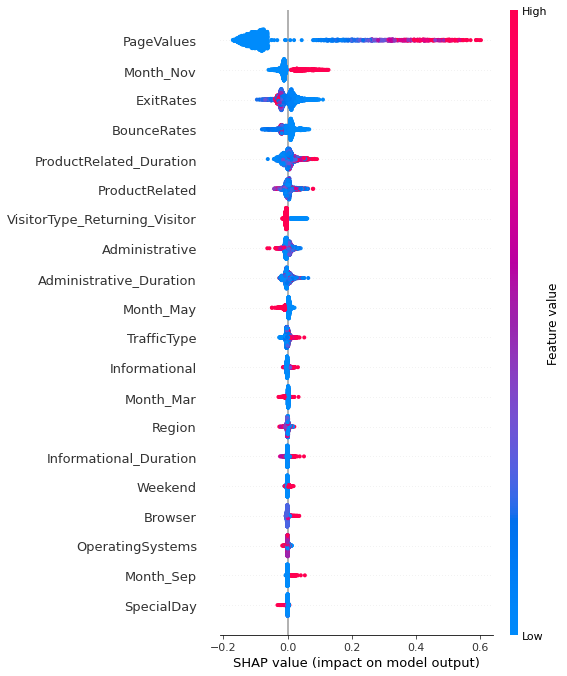

In [250]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_test,
    plot_type="dot"
)

In [251]:
customer = 0

In [252]:
shap_value = shap_values[customer, :, 1]

In [253]:
explanation = shap.Explanation(
    values=shap_value,
    base_values=explainer.expected_value[1],
    data=X_test.iloc[customer],
    feature_names=X_test.columns
)

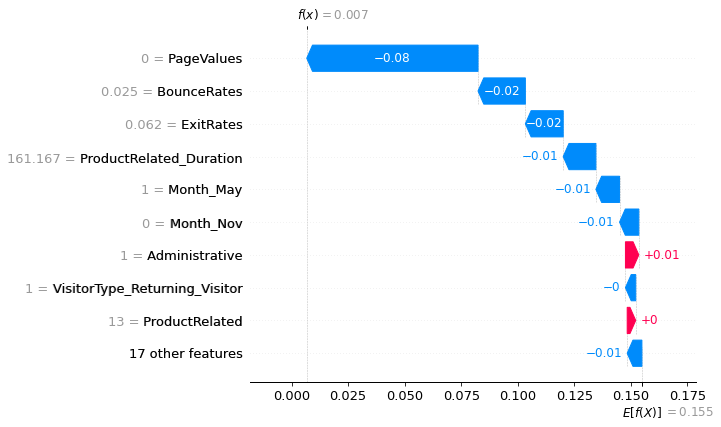

In [254]:
shap.plots.waterfall(explanation)

**# ROC Curve Comparison

In [255]:
from sklearn.metrics import roc_curve, auc

In [256]:
models = [
    ("Logistic Regression", log_reg, X_test_scaled),
    ("Balanced Logistic", log_reg_balanced, X_test_scaled),
    ("Decision Tree", decision_tree, X_test),
    ("Random Forest", random_forest, X_test),
    ("Tuned RF", best_rf, X_test),
    ("KNN", knn, X_test_scaled),
    ("SVM", svm, X_test_scaled),
    ("Naive Bayes", naive_bayes, X_test)
]

C:\Users\kaniz\anaconda3\lib\site-packages\sklearn\base.py:443: UserWarning: X has feature names, but GaussianNB was fitted without feature names
  warnings.warn(


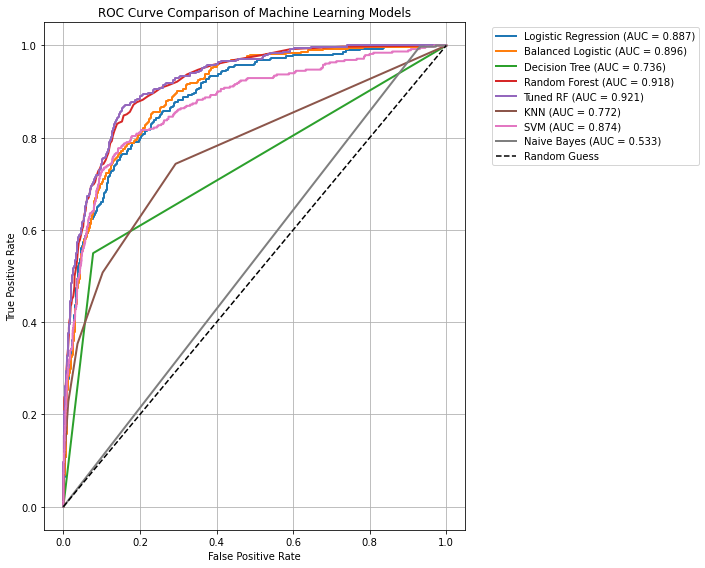

In [257]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

for name, model, X in models:

    # Predict probabilities
    y_prob = model.predict_proba(X)[:, 1]

    # ROC points
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    # Plot ROC curve
    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{name} (AUC = {auc(fpr, tpr):.3f})"
    )

# Random guessing line
plt.plot([0,1], [0,1], "k--", label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison of Machine Learning Models")
plt.legend(
    bbox_to_anchor=(1.05,1),
    loc="upper left"
)

plt.tight_layout()
plt.grid(True)

plt.show()

# Conclusion

Seven machine learning algorithms were evaluated for predicting online shopper purchasing intention.

Among all models, the Tuned Random Forest achieved the best overall performance with:

- Accuracy: 90.15%
- Precision: 74.91%
- Recall: 54.71%
- F1-score: 63.24%
- ROC-AUC: 92.08%

Feature importance analysis and SHAP explainability consistently identified PageValues, ExitRates, BounceRates, and ProductRelated behaviour as the most influential predictors of purchase intention.

These findings demonstrate that ensemble learning methods combined with Explainable AI can effectively predict customer purchasing behaviour while providing interpretable insights for business decision-making.